# Notebook 10 — RL vs Analytical Market Making

**References**:
- Guéant (2017), *Optimal Market Making*
- Falces Marin et al. (2022), PLOS ONE — RL controls γ of Avellaneda-Stoikov
- ISAC (GitHub im1235) — SAC controls γ in A-S model

## Approach
Instead of having RL learn quotes directly, the agent learns a
**state-dependent risk aversion** γ(t, n), then quotes are computed
analytically via the Guéant closed-form formulas.

This hybrid approach:
- Inherits structural guarantees of the Guéant framework
- Allows adaptive risk management
- Is interpretable (we can visualise the learned γ map)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys
sys.path.append(str(Path().resolve().parents[0]))

from market_making.core.closed_form import approx_quotes
from market_making.core.intensity import fill_prob
from market_making.core.hawkes import HawkesState, softplus

plt.style.use("seaborn-v0_8")

## Environment

In [2]:
class MarketMakingEnv:
    """Gym-like environment for MM with Poisson or Hawkes fills."""

    def __init__(self, params, T=3600.0, N_t=360, fill_mode="poisson",
                 hawkes_cfg=None, inv_penalty=0.01, seed=None):
        self.params = params
        self.sigma, self.A, self.k = params["sigma"], params["A"], params["k"]
        self.Delta, self.Q = params["Delta"], int(params["Q"])
        self.T, self.N_t = T, N_t
        self.dt = T / N_t
        self.fill_mode = fill_mode
        self.inv_penalty = inv_penalty
        self.rng = np.random.default_rng(seed)
        self.hawkes_cfg = hawkes_cfg or {"beta": 10.0, "alpha_self": 2.0, "alpha_cross": 0.5}
        self.reset()

    def reset(self):
        self.S, self.X, self.n, self.t_idx = 0.0, 0.0, 0, 0
        self.y_bid, self.y_ask = 0.0, 0.0
        return (self.n, self.t_idx)

    def step(self, gamma_action):
        mtm_old = self.X + self.n * self.Delta * self.S
        xi = gamma_action
        try:
            db, da = approx_quotes(np.array([self.n]), self.params, gamma_action, xi=xi)
            db, da = max(float(db[0]), 1e-8), max(float(da[0]), 1e-8)
        except Exception:
            db = da = 1.0 / self.k

        self.S += self.sigma * np.sqrt(self.dt) * self.rng.standard_normal()

        lam_b = self.A * np.exp(-self.k * db)
        lam_a = self.A * np.exp(-self.k * da)

        if self.fill_mode == "hawkes":
            lam_b = float(softplus(np.array([lam_b + self.y_bid])))
            lam_a = float(softplus(np.array([lam_a + self.y_ask])))
            beta = self.hawkes_cfg["beta"]
            self.y_bid *= np.exp(-beta * self.dt)
            self.y_ask *= np.exp(-beta * self.dt)

        bf = self.rng.random() < fill_prob(lam_b, self.dt)
        af = self.rng.random() < fill_prob(lam_a, self.dt)

        if bf and self.n < self.Q:
            self.X -= (self.S - db) * self.Delta; self.n += 1
        if af and self.n > -self.Q:
            self.X += (self.S + da) * self.Delta; self.n -= 1

        if self.fill_mode == "hawkes":
            a_s, a_c = self.hawkes_cfg["alpha_self"], self.hawkes_cfg["alpha_cross"]
            if bf: self.y_bid += a_s; self.y_ask += a_c
            if af: self.y_ask += a_s; self.y_bid += a_c

        self.t_idx += 1
        mtm_new = self.X + self.n * self.Delta * self.S
        reward = (mtm_new - mtm_old) - self.inv_penalty * abs(self.n) * self.Delta * self.sigma * np.sqrt(self.dt)
        done = self.t_idx >= self.N_t
        return (self.n, self.t_idx), float(reward), done

## Q-Learning Agent

In [3]:
class QLearningAgent:
    def __init__(self, Q_max=4, n_time_buckets=10, gamma_levels=None,
                 lr=0.1, discount=0.99, eps_start=1.0, eps_end=0.05, eps_decay=0.995):
        self.Q_max = Q_max
        self.n_inv = 2 * Q_max + 1
        self.n_time = n_time_buckets
        self.gamma_levels = gamma_levels or [0.002, 0.01, 0.05]
        self.n_actions = len(self.gamma_levels)
        self.q_table = np.zeros((self.n_inv, self.n_time, self.n_actions))
        self.lr, self.discount = lr, discount
        self.eps, self.eps_end, self.eps_decay = eps_start, eps_end, eps_decay

    def _disc(self, state, N_t):
        n, t = state
        ib = int(np.clip(n + self.Q_max, 0, self.n_inv - 1))
        tb = int(np.clip(t * self.n_time / max(N_t, 1), 0, self.n_time - 1))
        return ib, tb

    def act(self, state, N_t):
        if np.random.random() < self.eps:
            return np.random.randint(self.n_actions)
        ib, tb = self._disc(state, N_t)
        return int(np.argmax(self.q_table[ib, tb]))

    def update(self, s, a, r, s2, done, N_t):
        ib, tb = self._disc(s, N_t)
        nib, ntb = self._disc(s2, N_t)
        target = r if done else r + self.discount * np.max(self.q_table[nib, ntb])
        self.q_table[ib, tb, a] += self.lr * (target - self.q_table[ib, tb, a])

    def decay(self):
        self.eps = max(self.eps_end, self.eps * self.eps_decay)

## Training

In [4]:
params = {"sigma": 5.76, "A": 5.55, "k": 2.73, "Delta": 91.86, "Q": 4}
N_EPISODES = 500
N_t_train = 360

agent = QLearningAgent(Q_max=4, gamma_levels=[0.002, 0.01, 0.05])
rewards = []
rng = np.random.default_rng(42)

for ep in range(N_EPISODES):
    env = MarketMakingEnv(params, T=3600, N_t=N_t_train, fill_mode="poisson",
                          seed=int(rng.integers(1e9)))
    state = env.reset()
    total = 0.0
    while True:
        a = agent.act(state, N_t_train)
        s2, r, done = env.step(agent.gamma_levels[a])
        agent.update(state, a, r, s2, done, N_t_train)
        state = s2; total += r
        if done: break
    agent.decay()
    rewards.append(total)

print(f"Trained {N_EPISODES} episodes. Final ε = {agent.eps:.3f}")

Trained 500 episodes. Final ε = 0.082


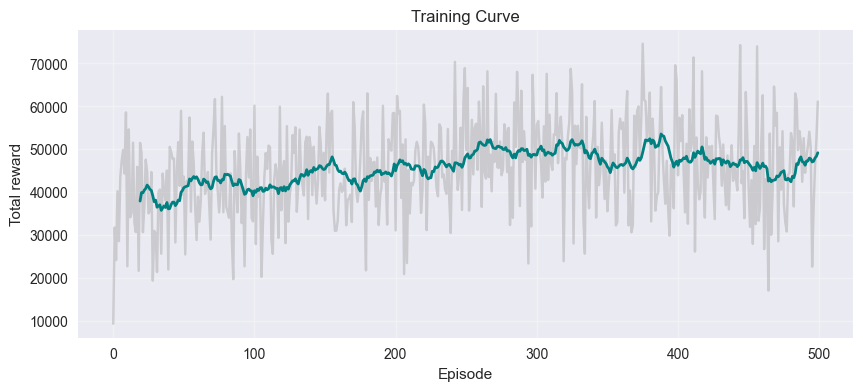

In [5]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(rewards, alpha=0.3, color="gray")
window = 20
smooth = np.convolve(rewards, np.ones(window)/window, mode="valid")
ax.plot(np.arange(window-1, len(rewards)), smooth, color="teal", linewidth=2)
ax.set_xlabel("Episode")
ax.set_ylabel("Total reward")
ax.set_title("Training Curve")
ax.grid(alpha=0.3)
plt.show()

## Learned Policy

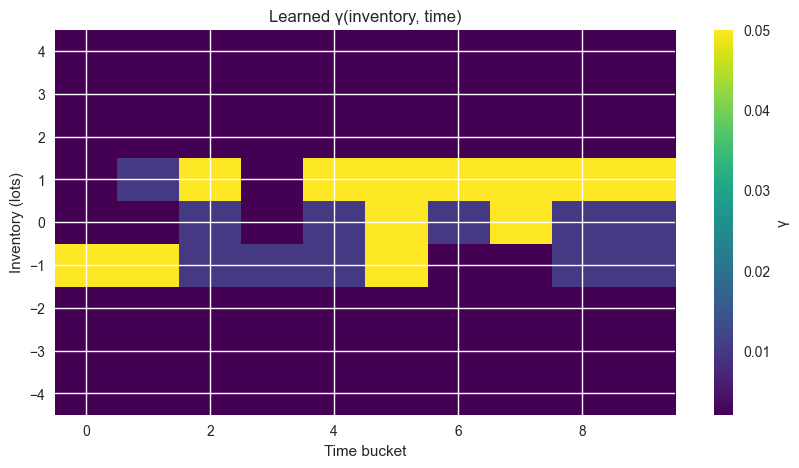

In [6]:
gamma_map = np.array(agent.gamma_levels)[np.argmax(agent.q_table, axis=2)]

fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(gamma_map, aspect="auto", cmap="viridis",
               extent=[-0.5, agent.n_time-0.5, -agent.Q_max-0.5, agent.Q_max+0.5])
plt.colorbar(im, label="γ")
ax.set_xlabel("Time bucket")
ax.set_ylabel("Inventory (lots)")
ax.set_title("Learned γ(inventory, time)")
plt.show()

## Benchmark: Poisson World

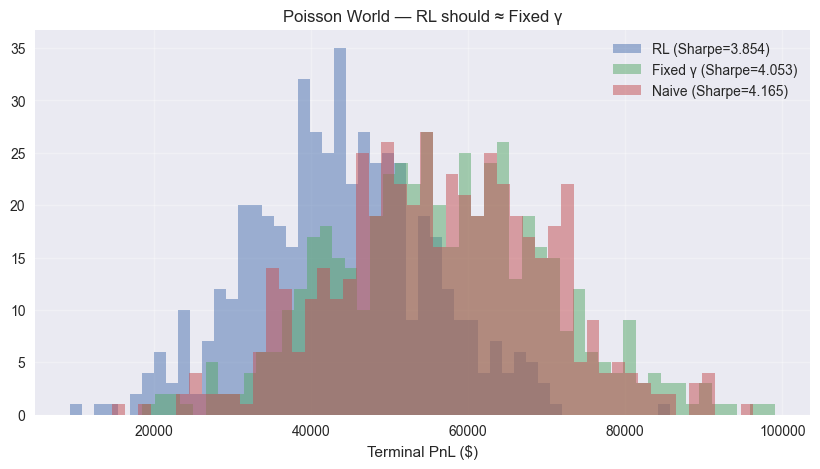

In [7]:
agent.eps = 0.0  # greedy
N_TEST = 500

def benchmark(agent, params, gamma_fixed, fill_mode="poisson", hawkes_cfg=None):
    rng = np.random.default_rng(123)
    results = {}
    for name, get_g in [("RL", lambda s: agent.gamma_levels[agent.act(s, N_t_train)]),
                         ("Fixed γ", lambda s: gamma_fixed),
                         ("Naive", lambda s: gamma_fixed)]:
        pnls = []
        for _ in range(N_TEST):
            env = MarketMakingEnv(params, T=3600, N_t=N_t_train, fill_mode=fill_mode,
                                  hawkes_cfg=hawkes_cfg, seed=int(rng.integers(1e9)))
            s = env.reset()
            while True:
                g = get_g(s)
                s, _, done = env.step(g)
                if done: break
            pnls.append(env.X + env.n * env.Delta * env.S)
        pnls = np.array(pnls)
        results[name] = {"pnl": pnls, "sharpe": float(np.mean(pnls)/max(np.std(pnls),1e-12))}
    return results

res_p = benchmark(agent, params, 0.01, "poisson")

fig, ax = plt.subplots(figsize=(10, 5))
for name, data in res_p.items():
    ax.hist(data["pnl"], bins=50, alpha=0.5, label=f"{name} (Sharpe={data['sharpe']:.3f})")
ax.set_xlabel("Terminal PnL ($)")
ax.legend()
ax.set_title("Poisson World — RL should ≈ Fixed γ")
ax.grid(alpha=0.3)
plt.show()

## Benchmark: Hawkes World

/var/folders/th/b_cdn0h107lcl7b1cp9xd7zc0000gn/T/ipykernel_19929/43425725.py:37: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  lam_b = float(softplus(np.array([lam_b + self.y_bid])))
/var/folders/th/b_cdn0h107lcl7b1cp9xd7zc0000gn/T/ipykernel_19929/43425725.py:38: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  lam_a = float(softplus(np.array([lam_a + self.y_ask])))


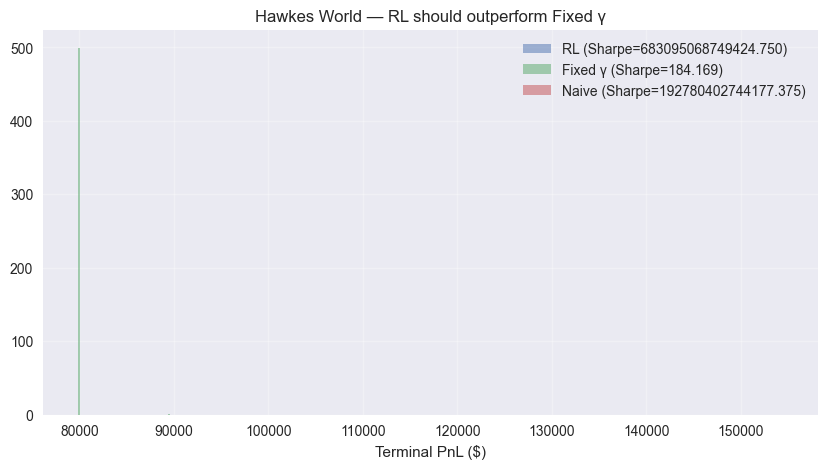

In [8]:
hawkes_cfg = {"beta": 10.0, "alpha_self": 2.0, "alpha_cross": 0.5}

# Train on Hawkes
agent_h = QLearningAgent(Q_max=4, gamma_levels=[0.002, 0.01, 0.05])
rewards_h = []
for ep in range(N_EPISODES):
    env = MarketMakingEnv(params, T=3600, N_t=N_t_train, fill_mode="hawkes",
                          hawkes_cfg=hawkes_cfg, seed=int(rng.integers(1e9)))
    s = env.reset()
    total = 0.0
    while True:
        a = agent_h.act(s, N_t_train)
        s2, r, done = env.step(agent_h.gamma_levels[a])
        agent_h.update(s, a, r, s2, done, N_t_train)
        s = s2; total += r
        if done: break
    agent_h.decay()
    rewards_h.append(total)

agent_h.eps = 0.0
res_h = benchmark(agent_h, params, 0.01, "hawkes", hawkes_cfg)

fig, ax = plt.subplots(figsize=(10, 5))
for name, data in res_h.items():
    ax.hist(data["pnl"], bins=50, alpha=0.5, label=f"{name} (Sharpe={data['sharpe']:.3f})")
ax.set_xlabel("Terminal PnL ($)")
ax.legend()
ax.set_title("Hawkes World — RL should outperform Fixed γ")
ax.grid(alpha=0.3)
plt.show()

### Key takeaways

1. **Poisson world**: RL ≈ analytical — both converge to similar policies.
2. **Hawkes world**: RL can outperform because it adapts to fill clustering.
3. The learned γ(t, n) map shows higher risk aversion at extreme inventories.